# Home vs Away Performance

Comparing each team's points, goals, xG, and results at home vs on the road in the 1. CFL 2025-26 season.

In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# ─── Path Configuration ──────────────────────────────────────────
DATA_DIR       = Path('..') / 'data' / 'processed'
RAW_DIR        = Path('..') / 'data' / 'raw' / 'mt1cfl_2526'
FIGURES_DIR    = Path('..') / 'outputs' / 'figures'
FINAL_DIR      = Path('..') / 'outputs' / 'final_posts'
TEAM_LOGOS_DIR = DATA_DIR / 'team_logos'
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# ─── Load Data ───────────────────────────────────────────────────
matches    = pd.read_csv(DATA_DIR / 'matches_metadata.csv', parse_dates=['match_datetime'])
team_stats = pd.read_csv(DATA_DIR / 'match_team_statistics.csv')
teams_meta = pd.read_csv(DATA_DIR / 'teams_metadata.csv')
standings  = pd.read_csv(DATA_DIR / 'league_standings.csv')

print(f'\u2705 Loaded {len(matches)} matches, {len(teams_meta)} teams')

✅ Loaded 125 matches, 10 teams


In [19]:
# ─── Build Home / Away Records ──────────────────────────────────
records = []

for _, m in matches.iterrows():
    h_id, a_id = m['homeTeam_id'], m['awayTeam_id']
    h_goals    = m['homeScore_total']
    a_goals    = m['awayScore_total']

    if pd.isna(h_goals) or pd.isna(a_goals):
        continue

    h_goals, a_goals = int(h_goals), int(a_goals)

    # Points
    if h_goals > a_goals:
        h_pts, a_pts = 3, 0
    elif h_goals == a_goals:
        h_pts, a_pts = 1, 1
    else:
        h_pts, a_pts = 0, 3

    # xG from team stats
    match_xg = team_stats[team_stats['match_id'] == m['match_id']]
    h_xg = match_xg.loc[match_xg['team_id'] == h_id, 'expectedGoals']
    a_xg = match_xg.loc[match_xg['team_id'] == a_id, 'expectedGoals']
    h_xg = float(h_xg.values[0]) if len(h_xg) > 0 and pd.notna(h_xg.values[0]) else 0.0
    a_xg = float(a_xg.values[0]) if len(a_xg) > 0 and pd.notna(a_xg.values[0]) else 0.0

    records.append({'team_id': h_id, 'venue': 'Home', 'gf': h_goals, 'ga': a_goals, 'pts': h_pts, 'xg': h_xg,
                    'win': int(h_goals > a_goals), 'draw': int(h_goals == a_goals), 'loss': int(h_goals < a_goals)})
    records.append({'team_id': a_id, 'venue': 'Away', 'gf': a_goals, 'ga': h_goals, 'pts': a_pts, 'xg': a_xg,
                    'win': int(a_goals > h_goals), 'draw': int(a_goals == h_goals), 'loss': int(a_goals < h_goals)})

df = pd.DataFrame(records)

# Aggregate per team per venue
agg = df.groupby(['team_id', 'venue'], as_index=False).agg(
    played = ('pts', 'count'),
    wins   = ('win', 'sum'),
    draws  = ('draw', 'sum'),
    losses = ('loss', 'sum'),
    gf     = ('gf', 'sum'),
    ga     = ('ga', 'sum'),
    pts    = ('pts', 'sum'),
    xg     = ('xg', 'sum'),
)
agg['ppg'] = (agg['pts'] / agg['played']).round(2)

# Merge metadata
agg = agg.merge(teams_meta[['team_id', 'short_name']], on='team_id', how='left')
agg = agg.merge(standings[['team_id', 'position']], on='team_id', how='left')

# Pivot for easy comparison
home = agg[agg['venue'] == 'Home'].set_index('team_id')
away = agg[agg['venue'] == 'Away'].set_index('team_id')

print(f'\u2705 Aggregated home/away stats for {agg["team_id"].nunique()} teams')
display(agg.sort_values(['position', 'venue']))

✅ Aggregated home/away stats for 10 teams


,team_id,venue,played,wins,draws,losses,gf,ga,pts,xg,ppg,short_name,position
6,6224,Away,12,5,3,4,16,16,18,11.02,1.50,Sutjeska,1
7,6224,Home,13,10,1,2,28,11,31,24.34,2.38,Sutjeska,1
14,36019,Away,13,5,2,6,13,16,17,15.22,1.31,Mornar,2
15,36019,Home,12,7,4,1,22,10,25,17.11,2.08,Mornar,2
8,6226,Away,12,4,4,4,11,16,16,10.83,1.33,Dečić,3
9,6226,Home,13,7,2,4,21,17,23,12.86,1.77,Dečić,3
12,24312,Away,12,3,4,5,12,17,13,11.05,1.08,Jezero,4
13,24312,Home,13,6,3,4,20,15,21,19.22,1.62,Jezero,4
2,6216,Away,12,4,3,5,16,17,15,12.13,1.25,Petrovac,5
3,6216,Home,13,7,5,1,21,7,26,15.10,2.00,Petrovac,5


In [ ]:
# ─── Color Constants ─────────────────────────────────────────────
BG_COLOR      = '#0a0a0a'
HOME_COLOR    = '#2ecc71'   # Green for home
AWAY_COLOR    = '#e74c3c'   # Red for away
GOLD          = '#d4af37'
TEXT_WHITE    = '#FFFFFF'
GRID_COLOR    = '#1a1a1a'

# ─── Sort teams by league position ───────────────────────────────
team_order = standings.sort_values('position')['team_id'].tolist()
short_names = teams_meta.set_index('team_id')['short_name']

home_ppg = [home.loc[tid, 'ppg'] if tid in home.index else 0 for tid in team_order]
away_ppg = [away.loc[tid, 'ppg'] if tid in away.index else 0 for tid in team_order]
home_gf  = [int(home.loc[tid, 'gf']) if tid in home.index else 0 for tid in team_order]
away_gf  = [int(away.loc[tid, 'gf']) if tid in away.index else 0 for tid in team_order]
home_ga  = [int(home.loc[tid, 'ga']) if tid in home.index else 0 for tid in team_order]
away_ga  = [int(away.loc[tid, 'ga']) if tid in away.index else 0 for tid in team_order]
labels   = [short_names.get(tid, str(tid)) for tid in team_order]

print('✅ Constants and data arrays ready')

✅ Constants and data arrays ready


✅ Saved: home_vs_away_goals.png


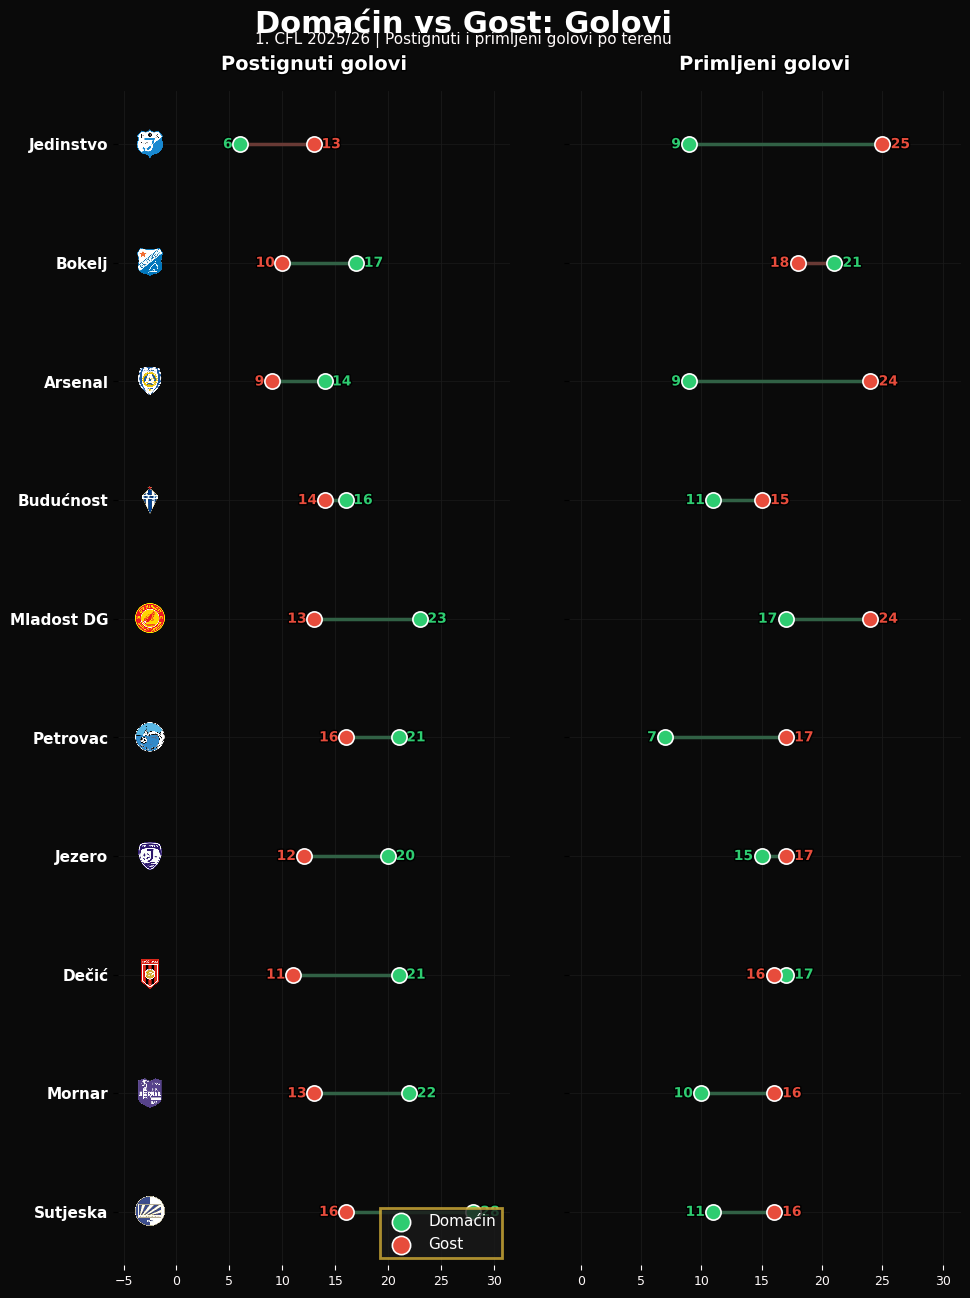

In [ ]:
# ─── Dumbbell Chart: Goals Scored & Conceded Home vs Away ────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.8, 13.5), dpi=100,
                                sharey=True, gridspec_kw={'wspace': 0.15})
fig.patch.set_facecolor(BG_COLOR)
ax1.set_facecolor(BG_COLOR)
ax2.set_facecolor(BG_COLOR)

y = np.arange(len(team_order))
DOT_SIZE = 120
LINE_COLOR = '#333333'

# ─── Left panel: Goals Scored (dumbbell) ─────────────────────────
for i in range(len(team_order)):
    # Connecting line
    ax1.plot([home_gf[i], away_gf[i]], [y[i], y[i]],
             color=LINE_COLOR, linewidth=2.5, zorder=2)
    # Highlight the gap with a subtle colored fill
    lo, hi = min(home_gf[i], away_gf[i]), max(home_gf[i], away_gf[i])
    gap_color = HOME_COLOR if home_gf[i] >= away_gf[i] else AWAY_COLOR
    ax1.plot([lo, hi], [y[i], y[i]], color=gap_color, linewidth=2.5, alpha=0.3, zorder=2)

# Dots
ax1.scatter(home_gf, y, s=DOT_SIZE, color=HOME_COLOR, edgecolors='white',
            linewidths=1.2, zorder=5, label='Domaćin')
ax1.scatter(away_gf, y, s=DOT_SIZE, color=AWAY_COLOR, edgecolors='white',
            linewidths=1.2, zorder=5, label='Gost')

# Value labels
for i in range(len(team_order)):
    # Home value
    offset_h = -0.7 if home_gf[i] <= away_gf[i] else 0.7
    ha_h = 'right' if home_gf[i] <= away_gf[i] else 'left'
    txt_h = ax1.text(home_gf[i] + offset_h, y[i], str(home_gf[i]),
                     va='center', ha=ha_h, fontsize=10, fontweight='bold', color=HOME_COLOR)
    txt_h.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                            path_effects.Normal()])
    # Away value
    offset_a = 0.7 if home_gf[i] <= away_gf[i] else -0.7
    ha_a = 'left' if home_gf[i] <= away_gf[i] else 'right'
    txt_a = ax1.text(away_gf[i] + offset_a, y[i], str(away_gf[i]),
                     va='center', ha=ha_a, fontsize=10, fontweight='bold', color=AWAY_COLOR)
    txt_a.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                            path_effects.Normal()])

# ─── Right panel: Goals Conceded (dumbbell) ──────────────────────
for i in range(len(team_order)):
    ax2.plot([home_ga[i], away_ga[i]], [y[i], y[i]],
             color=LINE_COLOR, linewidth=2.5, zorder=2)
    lo, hi = min(home_ga[i], away_ga[i]), max(home_ga[i], away_ga[i])
    gap_color = HOME_COLOR if home_ga[i] <= away_ga[i] else AWAY_COLOR
    ax2.plot([lo, hi], [y[i], y[i]], color=gap_color, linewidth=2.5, alpha=0.3, zorder=2)

ax2.scatter(home_ga, y, s=DOT_SIZE, color=HOME_COLOR, edgecolors='white',
            linewidths=1.2, zorder=5)
ax2.scatter(away_ga, y, s=DOT_SIZE, color=AWAY_COLOR, edgecolors='white',
            linewidths=1.2, zorder=5)

for i in range(len(team_order)):
    offset_h = -0.7 if home_ga[i] <= away_ga[i] else 0.7
    ha_h = 'right' if home_ga[i] <= away_ga[i] else 'left'
    txt_h = ax2.text(home_ga[i] + offset_h, y[i], str(home_ga[i]),
                     va='center', ha=ha_h, fontsize=10, fontweight='bold', color=HOME_COLOR)
    txt_h.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                            path_effects.Normal()])
    offset_a = 0.7 if home_ga[i] <= away_ga[i] else -0.7
    ha_a = 'left' if home_ga[i] <= away_ga[i] else 'right'
    txt_a = ax2.text(away_ga[i] + offset_a, y[i], str(away_ga[i]),
                     va='center', ha=ha_a, fontsize=10, fontweight='bold', color=AWAY_COLOR)
    txt_a.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                            path_effects.Normal()])

# ─── Team logos on left axis ─────────────────────────────────────
for i, tid in enumerate(team_order):
    logo_path = TEAM_LOGOS_DIR / f'{tid}.png'
    if logo_path.exists():
        try:
            logo = plt.imread(str(logo_path))
            im = OffsetImage(logo, zoom=0.14)
            ab = AnnotationBbox(im, (-2.5, y[i]), xycoords='data', frameon=False, zorder=10)
            ax1.add_artist(ab)
        except Exception:
            pass

# ─── Labels & styling ───────────────────────────────────────────
ax1.set_yticks(y)
ax1.set_yticklabels(labels, fontsize=11, color=TEXT_WHITE, fontweight='600')
ax1.invert_yaxis()
ax2.invert_yaxis()

# Panel titles
for ax, title_text in [(ax1, 'Postignuti golovi'), (ax2, 'Primljeni golovi')]:
    t = ax.set_title(title_text, fontsize=14, fontweight='bold', color=TEXT_WHITE, pad=15)
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                        path_effects.Normal()])

# Axis styling
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis='x', colors=TEXT_WHITE, labelsize=9)
    # Horizontal reference lines per team row
    for yi in y:
        ax.axhline(yi, color=GRID_COLOR, linewidth=0.5, zorder=0)
    ax.grid(axis='x', color=GRID_COLOR, linewidth=0.6, zorder=0)

max_val = max(max(home_gf), max(away_gf), max(home_ga), max(away_ga))
ax1.set_xlim(-5.5, max_val + 3.5)
ax2.set_xlim(-1.0, max_val + 3.5)

# Main title
fig.suptitle('Domaćin vs Gost: Golovi',
             fontsize=22, fontweight='bold', color=TEXT_WHITE, y=0.97)
fig.text(0.5, 0.945, '1. CFL 2025/26 | Postignuti i primljeni golovi po terenu',
         fontsize=11, color=TEXT_WHITE, ha='center')

# Legend
legend = ax1.legend(loc='lower right', frameon=True, fancybox=False, fontsize=11,
                    edgecolor=GOLD, facecolor='#1a1a1a', labelcolor=TEXT_WHITE,
                    markerscale=1.2)
legend.get_frame().set_linewidth(2)

fig.subplots_adjust(left=0.18, right=0.96, top=0.91, bottom=0.04)
plt.savefig(FIGURES_DIR / 'home_vs_away_goals.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: home_vs_away_goals.png')
plt.show()

✅ Saved Instagram post: home_vs_away_post.png (1080x1350px, ratio 0.800)


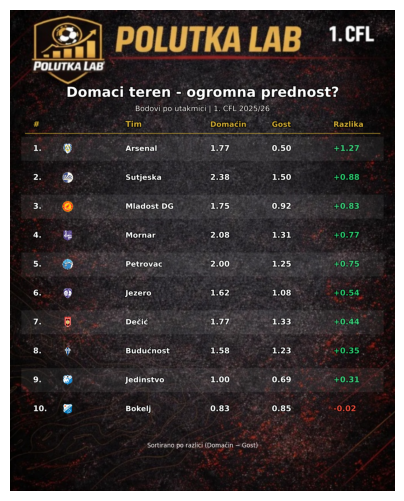

In [ ]:
# ─── Instagram 4:5 Composite Post ───────────────────────────────
# Build a combined summary table on the branded background

INSTAGRAM_SIZE = (1080, 1350)
BKG_PATH = FIGURES_DIR / 'background.png'
LOGO_PATH = FIGURES_DIR / 'pfp.png'

background_img = Image.open(BKG_PATH)
if background_img.size != INSTAGRAM_SIZE:
    background_img = background_img.resize(INSTAGRAM_SIZE, Image.Resampling.LANCZOS)
background_array = np.array(background_img)

fig, ax = plt.subplots(figsize=(10.8, 13.5), dpi=100)
ax.axis('off')
ax.set_position([0, 0, 1, 1])
ax.imshow(background_array, aspect='auto', extent=[0, 1, 0, 1], zorder=0)

# Title
title = ax.text(0.5, 0.84, 'Domaci teren - ogromna prednost?',
                transform=fig.transFigure, fontsize=28, fontweight='bold',
                ha='center', va='top', color='white')
title.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'),
                        path_effects.Normal()])

subtitle = ax.text(0.5, 0.80, 'Bodovi po utakmici | 1. CFL 2025/26',
                   transform=fig.transFigure, fontsize=15, fontweight='normal',
                   ha='center', va='top', color=TEXT_WHITE)
subtitle.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                           path_effects.Normal()])

# ─── Sort teams by home-away PPG difference ─────────────────────
row_data = []
for tid in team_order:
    h_ppg = home.loc[tid, 'ppg'] if tid in home.index else 0.0
    a_ppg = away.loc[tid, 'ppg'] if tid in away.index else 0.0
    row_data.append({'team_id': tid, 'h_ppg': h_ppg, 'a_ppg': a_ppg, 'diff': h_ppg - a_ppg})
row_data.sort(key=lambda r: r['diff'], reverse=True)

# ─── Table Layout ────────────────────────────────────────────────
col_x = [0.06, 0.15, 0.30, 0.52, 0.68, 0.84]  # rank, logo, team, home, away, diff
header_y = 0.76
row_start_y = 0.71
row_spacing = 0.060

# Column headers
headers = ['#', '', 'Tim', 'Domaćin', 'Gost', 'Razlika']
header_sizes = [16, 16, 16, 15, 15, 15]
for x, h, fs in zip(col_x, headers, header_sizes):
    txt = ax.text(x, header_y, h, transform=fig.transFigure, fontsize=fs,
                  fontweight='bold', color=GOLD, va='center')
    txt.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                          path_effects.Normal()])

# Separator line
ax.plot([0.04, 0.96], [header_y - 0.018, header_y - 0.018],
        transform=fig.transFigure, color=GOLD, linewidth=2, alpha=0.6, clip_on=False)

# Rows
for i, rd in enumerate(row_data):
    tid = rd['team_id']
    row_y = row_start_y - i * row_spacing
    name = short_names.get(tid, str(tid))
    h_ppg = rd['h_ppg']
    a_ppg = rd['a_ppg']
    diff = rd['diff']

    # Alternate row shading (stronger contrast)
    if i % 2 == 0:
        rect = plt.Rectangle((0.03, row_y - 0.025), 0.94, 0.050,
                              transform=fig.transFigure, facecolor='white',
                              alpha=0.07, zorder=1)
        fig.add_artist(rect)

    # Rank (by difference, not league position)
    rank_txt = ax.text(col_x[0], row_y, f'{i + 1}.',
                       transform=fig.transFigure, fontsize=16, fontweight='bold',
                       color=TEXT_WHITE, va='center')
    rank_txt.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                               path_effects.Normal()])

    # Team logo
    logo_path = TEAM_LOGOS_DIR / f'{tid}.png'
    if logo_path.exists():
        try:
            logo = plt.imread(str(logo_path))
            im = OffsetImage(logo, zoom=0.14)
            ab = AnnotationBbox(im, (col_x[1], row_y),
                                xycoords=fig.transFigure, frameon=False, zorder=10)
            fig.add_artist(ab)
        except Exception:
            pass

    # Team name
    name_txt = ax.text(col_x[2], row_y, name,
                       transform=fig.transFigure, fontsize=15, fontweight='600',
                       color=TEXT_WHITE, va='center')
    name_txt.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                               path_effects.Normal()])

    # Home PPG — white text
    home_txt = ax.text(col_x[3], row_y, f'{h_ppg:.2f}',
                       transform=fig.transFigure, fontsize=16, fontweight='bold',
                       color=TEXT_WHITE, va='center')
    home_txt.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                               path_effects.Normal()])

    # Away PPG — white text
    away_txt = ax.text(col_x[4], row_y, f'{a_ppg:.2f}',
                       transform=fig.transFigure, fontsize=16, fontweight='bold',
                       color=TEXT_WHITE, va='center')
    away_txt.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                               path_effects.Normal()])

    # Difference — green/red only here
    diff_color = HOME_COLOR if diff > 0 else (AWAY_COLOR if diff < 0 else TEXT_WHITE)
    diff_sign = '+' if diff > 0 else ''
    diff_txt = ax.text(col_x[5], row_y, f'{diff_sign}{diff:.2f}',
                       transform=fig.transFigure, fontsize=16, fontweight='bold',
                       color=diff_color, va='center')
    diff_txt.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                               path_effects.Normal()])

# Footer legend
ax.text(0.5, 0.09, 'Sortirano po razlici (Domaćin \u2212 Gost)',
        transform=fig.transFigure, fontsize=12, color=TEXT_WHITE, ha='center')

output_path = FINAL_DIR / 'home_vs_away_post.png'
fig.savefig(output_path, dpi=100, format='png')
plt.close(fig)

# Verify dimensions
img = Image.open(output_path)
w, h = img.size
print(f'\u2705 Saved Instagram post: {output_path.name} ({w}x{h}px, ratio {w/h:.3f})')
plt.figure(figsize=(5, 6.25))
plt.imshow(img)
plt.axis('off')
plt.show()